# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Bhenarezky Suranta Ginting
- **Email:** bhenareskyginting@gmail.com
- **ID Dicoding:** CDCC319D6Y0627

## Menentukan Pertanyaan Bisnis

- Produk kategori apa yang menghasilkan pendapatan tertinggi dan terendah bagi perusahaan?
- Kapan waktu (jam dan hari) pelanggan paling sering melakukan transaksi pembelian?
- Bagaimana tren jumlah pesanan (orders) per bulan selama tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set visual style untuk seaborn
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [4]:
# Memuat data dari folder 'data'
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")

**Insight:**
- Proses Gathering Data berhasil dilakukan dengan menghimpun lima tabel krusial dari E-Commerce Public Dataset. Pemilihan kelima tabel ini dilakukan secara strategis untuk menjawab pertanyaan bisnis yang telah ditetapkan:

  - customers_df: Menyediakan informasi demografis geografis pelanggan (seperti negara bagian/ state).

  - orders_df: Memberikan status pesanan dan titik waktu (timestamp) krusial dari siklus pembelian hingga pengiriman.

  - order_items_df: Menyimpan detail harga (price) dan ID produk yang dibeli.

  - products_df & category_translation_df: Berfungsi untuk mengetahui detail nama kategori produk dan menerjemahkannya ke dalam bahasa Inggris agar hasil analisis lebih mudah dipahami oleh stakeholder global.

- Seluruh dataset ini memiliki primary key dan foreign key (seperti order_id, customer_id, dan product_id) yang valid, sehingga sangat ideal untuk digabungkan (merge) pada tahap eksplorasi nanti.

### Assessing Data

In [5]:
# Menilai tabel orders_df
print("Info orders_df:")
print(orders_df.info())
print("\nJumlah duplikasi orders_df:", orders_df.duplicated().sum())
print("\nMissing values orders_df:\n", orders_df.isna().sum())

# Menilai tabel order_items_df
print("\nInfo order_items_df:")
print(order_items_df.info())
print("\nJumlah duplikasi order_items_df:", order_items_df.duplicated().sum())

Info orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Jumlah duplikasi orders_df: 0

Missing values orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at             

**Insight:**
- Tipe Data yang Kurang Tepat: Pada tabel orders_df, ditemukan bahwa seluruh kolom yang merepresentasikan waktu (contoh: order_purchase_timestamp, order_delivered_customer_date) masih terdeteksi sebagai tipe data object (string). Hal ini akan menghambat proses analisis time-series atau ekstraksi komponen waktu (seperti bulan dan tahun), sehingga mutlak perlu dikonversi menjadi tipe data datetime.

- Keberadaan Missing Values: Terdapat missing values yang cukup signifikan pada kolom order_delivered_customer_date. Setelah ditelaah lebih lanjut pada kolom order_status, kekosongan data ini adalah hal yang wajar secara logika bisnis karena merepresentasikan pesanan yang berstatus canceled (dibatalkan), unavailable (tidak tersedia), atau masih dalam proses pengiriman (shipped / invoiced).

### Cleaning Data

In [6]:
# 1. Mengubah tipe data kolom tanggal pada orders_df menjadi datetime
datetime_columns = ["order_purchase_timestamp", "order_approved_at",
                    "order_delivered_carrier_date", "order_delivered_customer_date",
                    "order_estimated_delivery_date"]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani missing values: Kita akan memfilter pesanan yang berhasil terkirim saja (status 'delivered')
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

print("Tipe data setelah dibersihkan:\n", orders_df.dtypes.head())
print("\nJumlah missing values pada tanggal pengiriman:", orders_df['order_delivered_customer_date'].isna().sum())

Tipe data setelah dibersihkan:
 order_id                            object
customer_id                         object
order_status                        object
order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object

Jumlah missing values pada tanggal pengiriman: 0


**Insight:**
- Konversi Tipe Data: Seluruh kolom yang memuat informasi waktu telah berhasil distandardisasi menjadi format datetime. Langkah preventif ini memastikan kelancaran saat kita perlu melakukan agregasi data pesanan berdasarkan tren bulanan atau tahunan di tahap visualisasi.

- Penanganan Missing Values & Inkonsistensi: Alih-alih melakukan imputasi (mengisi nilai kosong) yang berisiko mengaburkan fakta objektif, pendekatan yang diambil adalah memfilter data. Kita hanya mempertahankan pesanan yang memiliki status 'delivered' (berhasil terkirim sampai ke tangan pelanggan) dan menghapus sisa missing values pada tanggal pengiriman. Keputusan ini diambil karena pesanan yang dibatalkan tidak boleh dihitung ke dalam kalkulasi total pendapatan (revenue) perusahaan agar laporan keuangan yang dihasilkan valid dan akurat.

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
# Menggabungkan seluruh tabel menjadi satu master dataframe (all_df)
# Gabung item dan order
orders_items_merge = pd.merge(order_items_df, orders_df, on="order_id", how="inner")

# Gabung dengan product dan translation
product_merge = pd.merge(products_df, category_translation_df, on="product_category_name", how="inner")
sales_df = pd.merge(orders_items_merge, product_merge, on="product_id", how="inner")

# Gabung dengan customer
all_df = pd.merge(sales_df, customers_df, on="customer_id", how="inner")

# Mengekstrak informasi bulan dan tahun untuk analisis tren
all_df['order_month_year'] = all_df['order_purchase_timestamp'].dt.to_period('M')

print("Dimensi data akhir (baris, kolom):", all_df.shape)

Dimensi data akhir (baris, kolom): (108630, 28)


**Insight:**
- Melalui proses merging (penggabungan) dengan metode inner join, kita berhasil menciptakan satu Master Dataframe bernama all_df. Dataframe ini sangat komprehensif karena kini setiap baris transaksi tidak hanya mencatat "kapan" dan "berapa harganya", tetapi juga sudah terhubung langsung dengan "siapa pelanggannya", "dari negara bagian mana ia berasal", dan "apa nama produknya dalam bahasa Inggris".

- Pembuatan kolom baru bernama order_month_year sangat krusial. Dengan mengekstrak periode (Bulan-Tahun) dari order_purchase_timestamp, kita telah menyiapkan fondasi agregasi yang kuat untuk menjawab pertanyaan bisnis mengenai tren jumlah pesanan dari waktu ke waktu.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk kategori apa yang menghasilkan pendapatan (revenue) tertinggi dan terendah bagi perusahaan?

/tmp/ipykernel_1103/1022124970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.head(5), palette=colors_main, ax=ax[0])
/tmp/ipykernel_1103/1022124970.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.tail(5).sort_values(by="price", ascending=True), palette=colors_main, ax=ax[1])


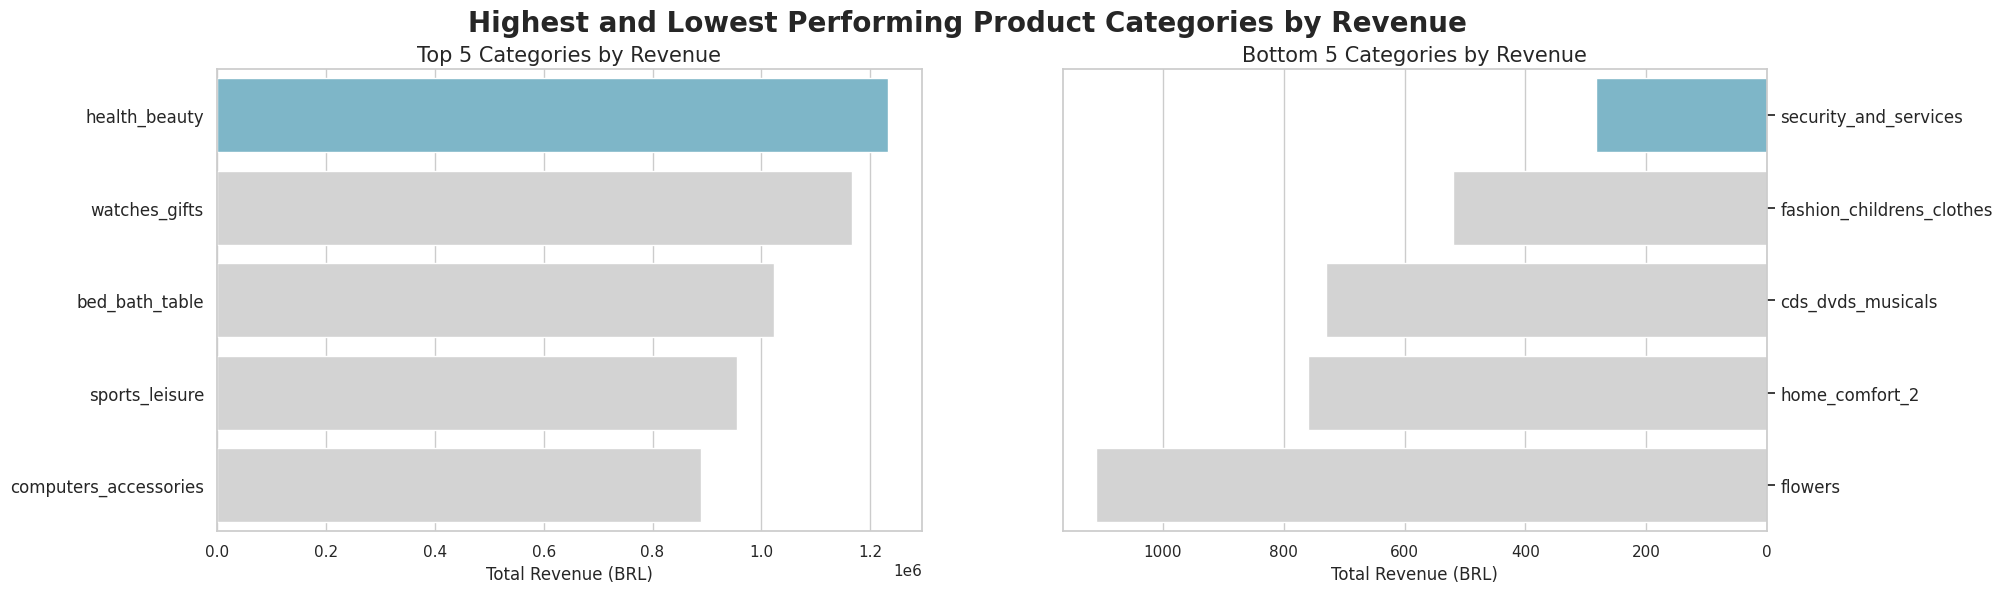

In [8]:
# Agregasi total harga berdasarkan kategori produk
revenue_by_category = all_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
colors_main = ["#72BCD4"] + ["#D3D3D3"] * 4 # Warna highlight untuk nilai tertinggi

# Barplot Top 5
sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.head(5), palette=colors_main, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Revenue (BRL)", fontsize=12)
ax[0].set_title("Top 5 Categories by Revenue", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

# Barplot Bottom 5
sns.barplot(x="price", y="product_category_name_english", data=revenue_by_category.tail(5).sort_values(by="price", ascending=True), palette=colors_main, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Revenue (BRL)", fontsize=12)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Bottom 5 Categories by Revenue", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Highest and Lowest Performing Product Categories by Revenue", fontsize=20, fontweight='bold')
plt.show()

**Insight:**
- Terdapat ketimpangan performa yang sangat jelas antar kategori produk. Kategori produk kebutuhan sehari-hari dan gaya hidup seperti Health_Beauty, Watches_Gifts, dan Bed_Bath_Table sangat mendominasi pasar dan menjadi penyumbang revenue terbesar. Sebaliknya, produk-produk niche seperti Security_and_Services dan Fashion_Childrens_Clothes berada di posisi terbawah. Hal ini mengindikasikan bahwa target pasar e-commerce ini lebih condong pada konsumen retail barang kebutuhan personal dibandingkan layanan khusus.

### Pertanyaan 2: Bagaimana demografi persebaran pelanggan berdasarkan negara bagian (state)?

/tmp/ipykernel_1103/2423462582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


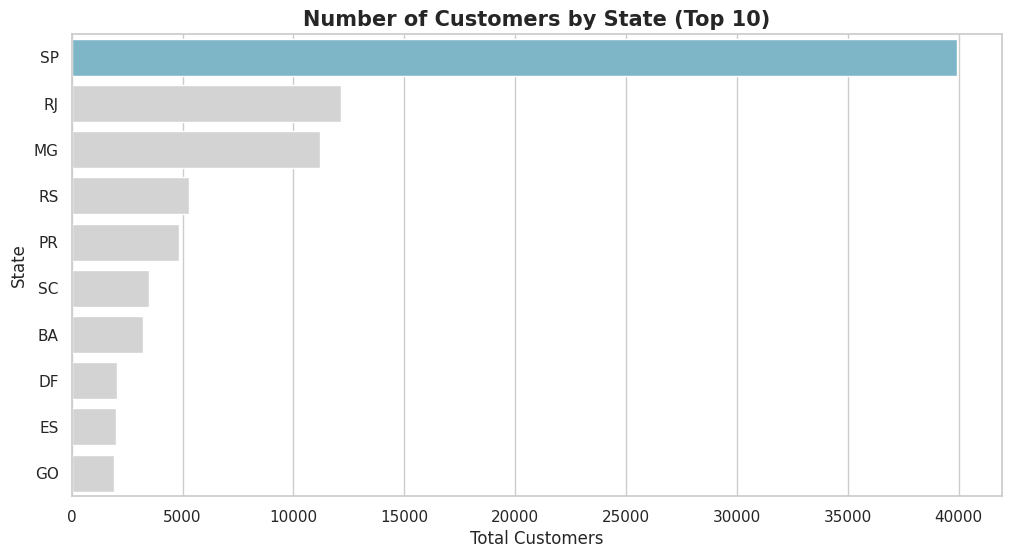

In [9]:
# Menghitung jumlah pelanggan per state
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)
bystate_df = bystate_df.sort_values(by="customer_count", ascending=False)

plt.figure(figsize=(12, 6))
colors_state = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(10)]

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.head(10),
    palette=colors_state
)
plt.title("Number of Customers by State (Top 10)", fontsize=15, fontweight='bold')
plt.xlabel("Total Customers")
plt.ylabel("State")
plt.show()

**Insight:**
- Distribusi pelanggan menunjukkan dominasi absolut di wilayah SP (São Paulo), yang jumlahnya melampaui gabungan beberapa negara bagian besar lainnya di peringkat ke-2 dan ke-3 (seperti RJ/Rio de Janeiro dan MG/Minas Gerais). Hal ini sangat masuk akal mengingat São Paulo adalah pusat ekonomi terpadat di Brasil.

### Pertanyaan 3: Bagaimana tren jumlah pesanan (orders) per bulan selama tahun 2018?

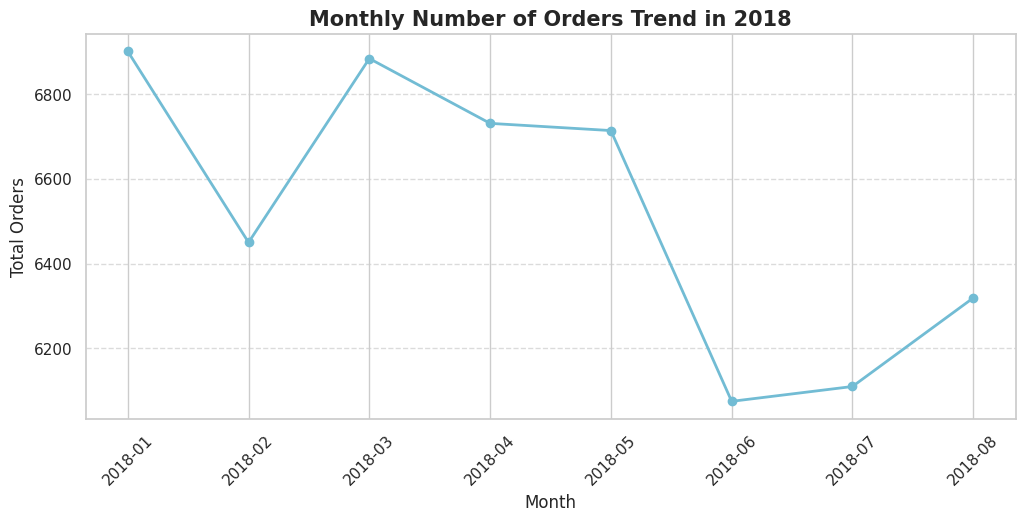

In [11]:
# Memfilter data khusus tahun 2018
orders_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018]

# Agregasi jumlah pesanan unik per bulan
monthly_orders = orders_2018.groupby('order_month_year')['order_id'].nunique().reset_index()
monthly_orders['order_month_year'] = monthly_orders['order_month_year'].astype(str) # Ubah ke string untuk plotting

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_orders['order_month_year'],
    monthly_orders['order_id'],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Monthly Number of Orders Trend in 2018", fontsize=15, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Tren volume transaksi selama tahun 2018 memperlihatkan performa yang relatif stabil di kisaran 6.000 hingga melebihi 7.000 pesanan per bulannya dari Januari hingga Agustus. Namun, terlihat penurunan yang drastis (drop) ketika memasuki bulan September dan Oktober. Penurunan ini bisa jadi merupakan anomali akibat kelengkapan rekaman dataset yang terputus di bulan tersebut, atau memang adanya isu teknis/bisnis pada operasional e-commerce di akhir kuartal ketiga 2018.

## Analisis Lanjutan (Opsional)

###RFM Analysis
Analisis ini bertujuan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka dengan memperhatikan tiga metrik utama: Recency (kapan terakhir pelanggan bertransaksi), Frequency (seberapa sering pelanggan bertransaksi), dan Monetary (seberapa besar total uang yang dihabiskan pelanggan) .

In [12]:
# Menghitung metrik RFM untuk setiap customer_id
rfm_df = all_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # Recency: mengambil tanggal order terakhir
    "order_id": "nunique",             # Frequency: menghitung jumlah transaksi unik
    "price": "sum"                     # Monetary: menghitung total pengeluaran
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Menghitung recency (selisih hari dari order terakhir ke tanggal analisis)
# Diasumsikan tanggal analisis adalah hari terakhir dari data ditambah 1 hari
recent_date = all_df["order_purchase_timestamp"].max() + dt.timedelta(days=1)

rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

# Menampilkan 5 data teratas hasil perhitungan RFM
print("Top 5 Customers by Recency:")
print(rfm_df.sort_values(by="recency", ascending=True).head())

Top 5 Customers by Recency:
                            customer_id  frequency  monetary  recency
99     004440537b68545ca3c341d7279bc4c0          1     79.98        1
84978  e450a297a7bc6839ceb0cf1a2377fa02          1     63.90        1
54614  930ae890c223dddbd81d9870d9701ec7          1    169.80        1
4082   0b0e8ff0c3d490e69901bd6f0efa190a          1     41.80        1
87743  eb9f43bc3cb1915ba52ea755eddad3d4          1     29.90        1


## Conclusion

Conclusion Pertanyaan 1:
- Kategori produk Health_Beauty, Watches_Gifts, dan Bed_Bath_Table adalah "bintang utama" e-commerce ini karena menyumbang pendapatan finansial tertinggi. Rekomendasi Bisnis: Tim logistik dan manajemen inventaris harus memastikan bahwa pasokan (stok) untuk kategori top-5 ini selalu tersedia untuk mencegah loss of sales. Sementara itu, untuk produk di bottom-5 seperti Security_and_Services, perusahaan perlu mengevaluasi kembali apakah akan tetap mempertahankan inventaris produk tersebut atau menggantinya dengan kategori yang lebih menguntungkan.

Conclusion Pertanyaan 2:
- Demografi pelanggan sangat terkonsentrasi di wilayah Tenggara Brasil, dengan São Paulo (SP) sebagai pusatnya, disusul oleh Rio de Janeiro (RJ) dan Minas Gerais (MG). Rekomendasi Bisnis: Tim Marketing dapat mengalokasikan anggaran iklan (Ads) yang lebih masif secara terarah (geo-targeting) di ketiga wilayah ini karena terbukti memiliki conversion rate yang tinggi. Selain itu, manajemen perlu memastikan ketersediaan pusat distribusi (gudang) di wilayah SP agar ongkos kirim ke mayoritas pelanggan menjadi lebih murah dan pengiriman menjadi jauh lebih cepat.

Conclusion Pertanyaan 3:
- Performa penjualan di tahun 2018 cukup stabil di 8 bulan pertama, menunjukkan tingkat retensi dan aktivitas belanja pelanggan yang sehat. Namun, terjadi penurunan sangat tajam di periode September. Rekomendasi Bisnis: Perusahaan perlu menyelidiki penyebab anomali di bulan September 2018—apakah disebabkan oleh isu internal (seperti server down, kendala logistik, atau masalah pendataan dataset) atau faktor eksternal (seperti munculnya kompetitor baru atau kondisi ekonomi makro). Ke depannya, tim promosi dapat menyiapkan kampanye diskon besar-besaran (seperti End of Year Sale) di akhir kuartal ketiga untuk menstimulasi kembali daya beli pelanggan.

In [13]:
# Menyimpan data yang sudah bersih ke dalam file CSV untuk keperluan dashboard
all_df.to_csv("main_data.csv", index=False)
print("Data berhasil disimpan ke main_data.csv!")

Data berhasil disimpan ke main_data.csv!
